# Análise de Dados - Camada Silver

Este notebook realiza análises exploratórias e verificações de qualidade dos dados da camada Silver (schema `dl`, tabela `tb_sinistros_silver`) já processados e armazenados no PostgreSQL.

## Imports das bibliotecas

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sqlalchemy import create_engine, text
import os
import warnings
warnings.filterwarnings('ignore')

## Configuração da conexão com o banco de dados

In [2]:
# Configuração do banco de dados PostgreSQL
DB_HOST = os.getenv("DB_HOST", "localhost")
DB_PORT = os.getenv("DB_PORT", "5432")
DB_NAME = os.getenv("DB_NAME", "sinistros_prf")
DB_USER = os.getenv("DB_USER", "prf_user")
DB_PASSWORD = os.getenv("DB_PASSWORD", "prf_pass")

# String de conexão
CONNECTION_STRING = f"postgresql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"

# Criar engine SQLAlchemy
engine = create_engine(CONNECTION_STRING, pool_size=10, max_overflow=20, echo=False)

print("Configuração do banco definida")
print(f"Host: {DB_HOST}:{DB_PORT}")
print(f"Database: {DB_NAME}")

# Testar conexão
try:
    with engine.connect() as conn:
        conn.execute(text("SELECT 1"))
    print("Conexão estabelecida com sucesso!")
except Exception as e:
    print(f"Erro na conexão: {e}")

Configuração do banco definida
Host: localhost:5432
Database: sinistros_prf
Conexão estabelecida com sucesso!


## Carregamento dos Dados da Camada Silver

In [3]:
# Carregar dados da tabela Silver no PostgreSQL
print("Carregando dados de dl.tb_sinistros_silver...")

query = "SELECT * FROM dl.tb_sinistros_silver"
df = pd.read_sql(query, engine)

print(f"\nDados carregados com sucesso!")
print(f"Total de registros: {len(df):,}")
print(f"Total de colunas: {len(df.columns)}")

Carregando dados de dl.tb_sinistros_silver...

Dados carregados com sucesso!
Total de registros: 981,790
Total de colunas: 50

Dados carregados com sucesso!
Total de registros: 981,790
Total de colunas: 50


# Verificação e Análise dos Dados

## Visão Geral do Dataset

In [4]:
# Informações gerais do dataset
print("INFORMAÇÕES DO DATASET\n")
print(f"Shape: {df.shape}")
print(f"\nTipos de dados:")
print(df.dtypes.value_counts())

print("Dados únicos:")
if 'sinistro_id' in df.columns:
    print(f"Sinistros únicos: {df['sinistro_id'].nunique():,}")
if 'id_envolvido' in df.columns:
    print(f"Pessoas envolvidas: {df['id_envolvido'].nunique():,}")
if 'veiculo_id' in df.columns:
    print(f"Veículos envolvidos: {df['veiculo_id'].nunique():,}")
if 'ano' in df.columns:
    print(f"Período: {df['ano'].min()} - {df['ano'].max()}")
if 'uf' in df.columns:
    print(f"UFs: {df['uf'].nunique()}")
if 'municipio' in df.columns:
    print(f"Municípios: {df['municipio'].nunique():,}")

INFORMAÇÕES DO DATASET

Shape: (981790, 50)

Tipos de dados:
object            32
float64           11
int64              6
datetime64[ns]     1
Name: count, dtype: int64
Dados únicos:
Sinistros únicos: 120,348
Pessoas envolvidas: 294,539
Veículos envolvidos: 230,691
Período: 2024 - 2025
UFs: 27
Municípios: 1,907
UFs: 27
Municípios: 1,907


## Verificação de Qualidade dos Dados

VERIFICAÇÃO DE OUTLIERS

Estatísticas de Idade:
Mínimo: 0.0
Máximo: 127.0
Média: 39.0
Mediana: 38.0


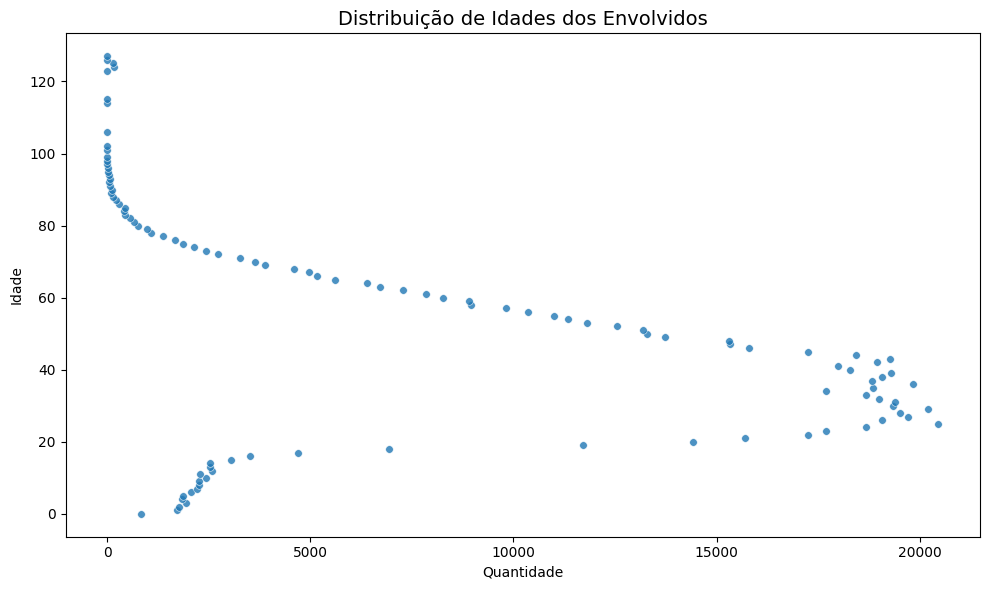


Estatísticas de Ano de Fabricação:
Mínimo: 1951
Máximo: 2025
Média: 2014


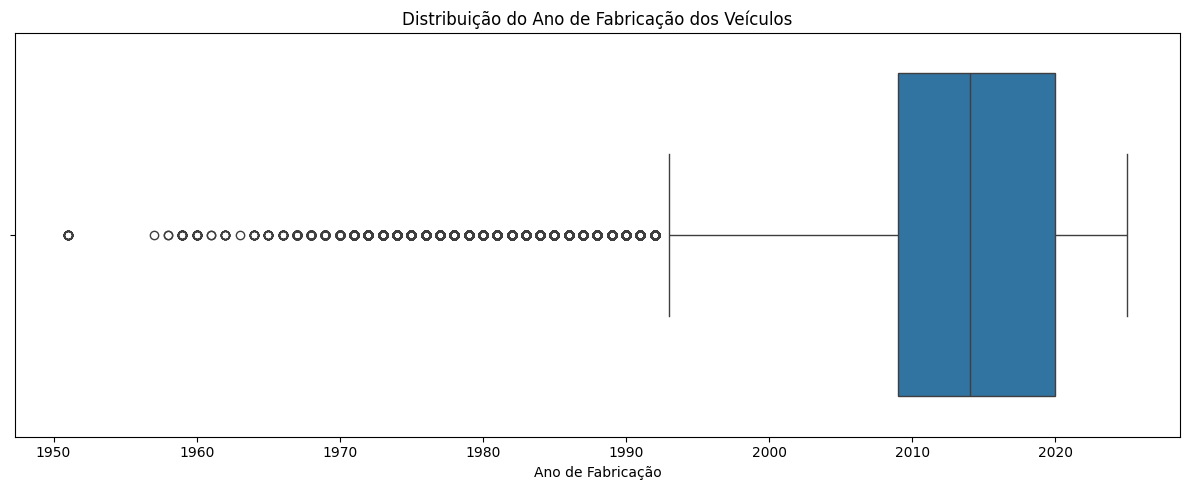

In [10]:
# Verificação de outliers e dados tratados
print("VERIFICAÇÃO DE OUTLIERS")

# Verificar tratamento de idade
if 'envolvido_idade' in df.columns:
    idade_stats = df['envolvido_idade'].describe()
    print("\nEstatísticas de Idade:")
    print(f"Mínimo: {idade_stats['min']}")
    print(f"Máximo: {idade_stats['max']}")
    print(f"Média: {idade_stats['mean']:.1f}")
    print(f"Mediana: {idade_stats['50%']}")
    
    # Visualizar distribuição de idade
    contagem_idade = df['envolvido_idade'].value_counts().sort_index()
    df_plot_frequencia = contagem_idade.reset_index()
    df_plot_frequencia.columns = ['envolvido_idade', 'Quantidade']
    
    plt.figure(figsize=(10, 6))
    sns.scatterplot(
        data=df_plot_frequencia,
        x='Quantidade',
        y='envolvido_idade',
        s=30,
        alpha=0.8
    )
    plt.title('Distribuição de Idades dos Envolvidos', fontsize=14)
    plt.xlabel('Quantidade')
    plt.ylabel('Idade')
    plt.tight_layout()
    plt.show()

# Verificar tratamento de ano de fabricação
if 'veiculo_ano_fabricacao' in df.columns:
    ano_stats = df['veiculo_ano_fabricacao'].describe()
    print("\nEstatísticas de Ano de Fabricação:")
    print(f"Mínimo: {int(ano_stats['min'])}")
    print(f"Máximo: {int(ano_stats['max'])}")
    print(f"Média: {ano_stats['mean']:.0f}")
    
    # Filtrar dados válidos para visualização
    df_ano_valido = df[df['veiculo_ano_fabricacao'].notna()]
    if 'veiculo_marca_modelo' in df.columns:
        df_ano_valido = df_ano_valido[
            ~df_ano_valido['veiculo_marca_modelo'].isin([
                'Não Informado/Não Informado', 'NA/NA', 'NaN', 'Outros'
            ])
        ]
    
    # Box plot de anos
    plt.figure(figsize=(12, 5))
    sns.boxplot(x=df_ano_valido['veiculo_ano_fabricacao'])
    plt.title('Distribuição do Ano de Fabricação dos Veículos', fontsize=12)
    plt.xlabel('Ano de Fabricação')
    plt.tight_layout()
    plt.show()

## Resumo Completo do Dataset

In [11]:
# Resumo detalhado de todas as colunas
print("RESUMO DETALHADO DAS COLUNAS")

n = len(df)
summary = []
for col in df.columns:
    ser = df[col]
    non_null = int(ser.notna().sum())
    nulls = int(n - non_null)
    pct_null = (nulls / n) * 100 if n > 0 else 0
    try:
        nunique = int(ser.nunique(dropna=True))
    except Exception:
        nunique = pd.NA
    sample = ser.dropna().astype(str).head(3).tolist()
    summary.append({
        'column': col,
        'dtype': str(ser.dtype),
        'non_null': non_null,
        'nulls': nulls,
        'pct_null': round(pct_null, 2),
        'nunique': nunique,
        'sample_values': ', '.join(sample[:3]) if sample else ''
    })

summary_df = pd.DataFrame(summary).set_index('column')

display(summary_df.sort_values('pct_null', ascending=False))

RESUMO DETALHADO DAS COLUNAS


,dtype,non_null,nulls,pct_null,nunique,sample_values
column,,,,,,
envolvido_idade,float64,801873,179917,18.33,110,"26.0, 34.0, 34.0"
faixa_etaria_classe,object,802985,178805,18.21,4,"Adulto, Adulto, Adulto"
faixa_etaria_ano,object,802985,178805,18.21,11,"20-29, 30-39, 30-39"
estado_fisico,object,886609,95181,9.69,5,"Óbito, Ileso, Ileso"
mortos,float64,886609,95181,9.69,2,"1.0, 0.0, 0.0"
feridos_leves,float64,886609,95181,9.69,2,"0.0, 0.0, 0.0"
ilesos,float64,886609,95181,9.69,2,"0.0, 1.0, 1.0"
envolvido_sexo,object,886609,95181,9.69,4,"Masculino, Feminino, Feminino"
id_envolvido,float64,886609,95181,9.69,294539,"1268971.0, 1268985.0, 1268985.0"


## Estatísticas Descritivas das Colunas Numéricas

In [12]:
# Estatísticas descritivas das principais colunas numéricas
colunas_numericas = [
    'envolvido_idade', 'veiculo_ano_fabricacao', 'quilometro', 
    'latitude', 'longitude', 'ilesos', 'feridos_leves', 
    'feridos_graves', 'feridos', 'mortos', 'ups', 'ano', 'hora'
]

colunas_existentes = [c for c in colunas_numericas if c in df.columns]

print("ESTATÍSTICAS DESCRITIVAS - COLUNAS NUMÉRICAS")

if colunas_existentes:
    display(df[colunas_existentes].describe())
else:
    print("Nenhuma coluna numérica encontrada para análise.")

ESTATÍSTICAS DESCRITIVAS - COLUNAS NUMÉRICAS


,envolvido_idade,veiculo_ano_fabricacao,quilometro,latitude,longitude,ilesos,feridos_leves,feridos_graves,feridos,mortos,ups,ano,hora
count,801873.000000,899199.000000,979475.000000,981790.000000,981790.000000,886609.000000,886609.000000,886609.000000,981790.000000,886609.000000,981790.000000,981790.000000,981790.000000
mean,38.959351,2013.725756,275.940057,-17.967304,-47.143976,0.410944,0.341142,0.127303,0.423031,0.054434,2.973489,2024.385597,12.860511
std,15.590693,8.110982,235.148954,7.887027,6.463890,0.492005,0.474093,0.333312,0.494041,0.226873,2.763590,0.486736,6.032596
min,0.000000,1951.000000,0.000000,-33.689326,-72.656072,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2024.000000,0.000000
25%,27.000000,2009.000000,84.000000,-24.821790,-51.134128,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2024.000000,8.000000
50%,38.000000,2014.000000,213.000000,-19.784960,-47.988753,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2024.000000,14.000000
75%,49.000000,2020.000000,427.000000,-11.361209,-42.789004,1.000000,1.000000,0.000000,1.000000,0.000000,4.000000,2025.000000,18.000000
max,127.000000,2025.000000,1470.000000,4.461419,-32.406822,1.000000,1.000000,1.000000,1.000000,1.000000,13.000000,2025.000000,23.000000


## Análises por Categoria

In [13]:
# Análise de distribuição por categoria
print("ANÁLISES CATEGÓRICAS")

# Análise por gravidade
if 'gravidade' in df.columns:
    print("Distribuição por Gravidade:")
    gravidade_dist = df['gravidade'].value_counts()
    for grav, count in gravidade_dist.items():
        pct = (count / len(df)) * 100
        print(f"{grav}: {count:,} ({pct:.1f}%)")
    print()

# Análise por região
if 'regiao' in df.columns:
    print("Distribuição por Região:")
    regiao_dist = df['regiao'].value_counts()
    for reg, count in regiao_dist.items():
        pct = (count / len(df)) * 100
        print(f"{reg}: {count:,} ({pct:.1f}%)")
    print()

# Análise por período do dia
if 'periodo' in df.columns:
    print("Distribuição por Período do Dia:")
    periodo_dist = df['periodo'].value_counts()
    for per, count in periodo_dist.items():
        pct = (count / len(df)) * 100
        print(f"{per}: {count:,} ({pct:.1f}%)")
    print()

# Análise por uso do solo
if 'uso_solo' in df.columns:
    print("Distribuição por Uso do Solo:")
    uso_dist = df['uso_solo'].value_counts()
    for uso, count in uso_dist.items():
        pct = (count / len(df)) * 100
        print(f"{uso}: {count:,} ({pct:.1f}%)")
    print()

# Top 10 tipos de sinistro
if 'sinistro_tipo' in df.columns:
    print("Top 10 Tipos de Sinistro:")
    tipo_dist = df['sinistro_tipo'].value_counts().head(10)
    for i, (tipo, count) in enumerate(tipo_dist.items(), 1):
        pct = (count / len(df)) * 100
        print(f"{i}. {tipo}: {count:,} ({pct:.1f}%)")
    print()

ANÁLISES CATEGÓRICAS
Distribuição por Gravidade:
Sem vítima: 518,200 (52.8%)
Com ferido: 415,328 (42.3%)
Com morto: 48,262 (4.9%)

Distribuição por Região:
Sul: 270,267 (27.5%)
Sudeste: 265,703 (27.1%)
Nordeste: 218,162 (22.2%)
Centro-Oeste: 138,966 (14.2%)
Norte: 88,692 (9.0%)

Distribuição por Período do Dia:
Tarde: 302,349 (30.8%)
Noite: 277,141 (28.2%)
Manhã: 276,288 (28.1%)
Madrugada: 126,012 (12.8%)

Distribuição por Uso do Solo:
Rural: 600,425 (61.2%)
Urbano: 381,365 (38.8%)

Top 10 Tipos de Sinistro:
1. Colisão traseira: 140,207 (14.3%)
2. Tombamento: 138,584 (14.1%)
3. Saída de leito carroçável: 124,148 (12.6%)
4. Queda de ocupante de veículo: 124,107 (12.6%)
5. Colisão com objeto: 77,128 (7.9%)
6. Colisão transversal: 76,312 (7.8%)
7. Colisão lateral mesmo sentido: 70,356 (7.2%)
8. Colisão frontal: 68,156 (6.9%)
9. Capotamento: 45,967 (4.7%)
10. Colisão lateral sentido oposto: 34,280 (3.5%)

Sul: 270,267 (27.5%)
Sudeste: 265,703 (27.1%)
Nordeste: 218,162 (22.2%)
Centro-Oeste:

## Amostra dos Dados

In [14]:
# Exibir amostra dos dados
print("AMOSTRA DOS DADOS (Primeiras 10 linhas)")

display(df.head(10))
print("ANÁLISE DA CAMADA SILVER CONCLUÍDA!")


AMOSTRA DOS DADOS (Primeiras 10 linhas)


,sinistro_id,id_envolvido,data,dia_semana,horario,uf,rodovia,quilometro,municipio,sinistro_causa_principal,...,ano,hora,periodo,periodo_semana,localidade,regiao,faixa_etaria_ano,faixa_etaria_classe,gravidade,ups
0,571772,1268971.0,2024-01-01,Segunda-feira,00:05:00,RJ,BR-101.0,272.5,TANGUA,Sim,...,2024,0,Madrugada,Segunda à Sexta,Rio de Janeiro,Sudeste,20-29,Adulto,Com morto,13
1,571774,1268985.0,2024-01-01,Segunda-feira,00:05:00,GO,BR-153.0,424.6,ANAPOLIS,Não,...,2024,0,Madrugada,Segunda à Sexta,Goiás,Centro-Oeste,30-39,Adulto,Sem vítima,1
2,571774,1268985.0,2024-01-01,Segunda-feira,00:05:00,GO,BR-153.0,424.6,ANAPOLIS,Sim,...,2024,0,Madrugada,Segunda à Sexta,Goiás,Centro-Oeste,30-39,Adulto,Sem vítima,1
3,571777,1269020.0,2024-01-01,Segunda-feira,01:45:00,ES,BR-101.0,264.1,SERRA,Sim,...,2024,1,Madrugada,Segunda à Sexta,Espírito Santo,Sudeste,50-59,Adulto,Sem vítima,1
4,571778,1269028.0,2024-01-01,Segunda-feira,00:45:00,SC,BR-101.0,110.0,PENHA,Não,...,2024,0,Madrugada,Segunda à Sexta,Santa Catarina,Sul,50-59,Adulto,Sem vítima,1
5,571778,1269045.0,2024-01-01,Segunda-feira,00:45:00,SC,BR-101.0,110.0,PENHA,Não,...,2024,0,Madrugada,Segunda à Sexta,Santa Catarina,Sul,30-39,Adulto,Com ferido,4
6,571778,1269028.0,2024-01-01,Segunda-feira,00:45:00,SC,BR-101.0,110.0,PENHA,Sim,...,2024,0,Madrugada,Segunda à Sexta,Santa Catarina,Sul,50-59,Adulto,Sem vítima,1
7,571778,1269045.0,2024-01-01,Segunda-feira,00:45:00,SC,BR-101.0,110.0,PENHA,Sim,...,2024,0,Madrugada,Segunda à Sexta,Santa Catarina,Sul,30-39,Adulto,Com ferido,4
8,571779,1268998.0,2024-01-01,Segunda-feira,01:45:00,RS,BR-116.0,236.0,NOVO HAMBURGO,Sim,...,2024,1,Madrugada,Segunda à Sexta,Rio Grande do Sul,Sul,0-9,Criança,Sem vítima,1
9,571779,1268999.0,2024-01-01,Segunda-feira,01:45:00,RS,BR-116.0,236.0,NOVO HAMBURGO,Sim,...,2024,1,Madrugada,Segunda à Sexta,Rio Grande do Sul,Sul,0-9,Criança,Sem vítima,1


ANÁLISE DA CAMADA SILVER CONCLUÍDA!
